# Módulo 4 — Ética, enviesamento e regulamentação

Este notebook corresponde ao Módulo 4 do projeto. O objetivo é analisar riscos éticos, enviesamento algorítmico, privacidade, supervisão humana e enquadramento regulamentar associados ao uso de modelos de IA para previsão de readmissão hospitalar em pacientes diabéticos.

A análise inclui a avaliação do desempenho do modelo por grupos sensíveis, como género, raça e idade, bem como uma discussão crítica sobre os riscos da utilização de sistemas de apoio à decisão em contexto de saúde.

In [26]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix

)

In [27]:
DATA_PATH = Path("../outputs/dados/diabetic_data_clean.csv")
MODEL_PATH = Path("../outputs/modelos/random_forest_afinado.pkl")

df_model = pd.read_csv(DATA_PATH)
best_rf_model = joblib.load(MODEL_PATH)

df_model.shape

(101766, 48)

In [28]:
# Algumas variáveis são códigos administrativos e devem ser tratadas como categóricas
coded_categorical_cols = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

for col in coded_categorical_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype("object")

target = "readmitted_30"

cols_to_exclude = [
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "readmitted_30"
]

X = df_model.drop(columns=cols_to_exclude)
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (20354, 44)
y_test: (20354,)


In [29]:
y_pred = best_rf_model.predict(X_test)
y_proba = best_rf_model.predict_proba(X_test)[:, 1]

print("Previsões geradas com sucesso.")

Previsões geradas com sucesso.


In [30]:
def group_performance_table(X_group, y_true, y_pred, group_col):
    results = []

    data = X_group.copy()
    data["y_true"] = y_true
    data["y_pred"] = y_pred

    for group_value, group_df in data.groupby(group_col):
        y_g_true = group_df["y_true"]
        y_g_pred = group_df["y_pred"]

        tn, fp, fn, tp = confusion_matrix(
            y_g_true,
            y_g_pred,
            labels=[0, 1]
        ).ravel()

        results.append({
            "grupo": group_value,
            "n": len(group_df),
            "accuracy": accuracy_score(y_g_true, y_g_pred),
            "precision": precision_score(y_g_true, y_g_pred, zero_division=0),
            "recall": recall_score(y_g_true, y_g_pred, zero_division=0),
            "f1_score": f1_score(y_g_true, y_g_pred, zero_division=0),
            "taxa_positivos_reais": y_g_true.mean(),
            "taxa_positivos_previstos": y_g_pred.mean(),
            "falsos_positivos": fp,
            "falsos_negativos": fn,
            "taxa_falsos_positivos": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "taxa_falsos_negativos": fn / (fn + tp) if (fn + tp) > 0 else np.nan
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

In [31]:
metrics_gender = group_performance_table(X_test, y_test, y_pred, "gender")
metrics_race = group_performance_table(X_test, y_test, y_pred, "race")
metrics_age = group_performance_table(X_test, y_test, y_pred, "age")

display(metrics_gender)
display(metrics_race)
display(metrics_age)

,grupo,n,accuracy,precision,recall,f1_score,taxa_positivos_reais,taxa_positivos_previstos,falsos_positivos,falsos_negativos,taxa_falsos_positivos,taxa_falsos_negativos
0,Female,10924,0.614976,0.179727,0.659761,0.282497,0.114885,0.421732,3779,427,0.390837,0.340239
1,Male,9430,0.632980,0.168430,0.611220,0.264087,0.107741,0.390986,3066,395,0.364393,0.388780


,grupo,n,accuracy,precision,recall,f1_score,taxa_positivos_reais,taxa_positivos_previstos,falsos_positivos,falsos_negativos,taxa_falsos_positivos,taxa_falsos_negativos
2,Caucasian,15223,0.615319,0.175982,0.654630,0.277394,0.112790,0.419563,5263,593,0.389679,0.345370
0,AfricanAmerican,3866,0.627522,0.172302,0.613426,0.269036,0.111743,0.397827,1273,167,0.370705,0.386574
5,Unknown,462,0.753247,0.153846,0.380952,0.219178,0.090909,0.225108,88,26,0.209524,0.619048
3,Hispanic,404,0.707921,0.230159,0.580000,0.329545,0.123762,0.311881,97,21,0.274011,0.420000
4,Other,276,0.655797,0.121212,0.600000,0.201681,0.072464,0.358696,87,8,0.339844,0.400000
1,Asian,123,0.642276,0.075000,0.300000,0.120000,0.081301,0.325203,37,7,0.327434,0.700000


,grupo,n,accuracy,precision,recall,f1_score,taxa_positivos_reais,taxa_positivos_previstos,falsos_positivos,falsos_negativos,taxa_falsos_positivos,taxa_falsos_negativos
7,[70-80),5234,0.586549,0.170951,0.635350,0.269413,0.119985,0.445930,1935,229,0.420104,0.364650
6,[60-70),4547,0.646580,0.184795,0.597353,0.282269,0.116340,0.376072,1394,213,0.346939,0.402647
5,[50-60),3457,0.696847,0.157654,0.571429,0.247126,0.087070,0.315592,919,129,0.291191,0.428571
8,[80-90),3414,0.509080,0.168432,0.750000,0.275087,0.124194,0.553017,1570,106,0.525084,0.250000
4,[40-50),1913,0.705698,0.199037,0.659574,0.305795,0.098275,0.325666,499,64,0.289275,0.340426
3,[30-40),725,0.699310,0.178899,0.500000,0.263514,0.107586,0.300690,179,39,0.276662,0.500000
9,[90-100),576,0.496528,0.153846,0.648649,0.248705,0.128472,0.541667,264,26,0.525896,0.351351
2,[20-30),324,0.716049,0.283186,0.744186,0.410256,0.132716,0.348765,81,11,0.288256,0.255814
1,[10-20),130,0.930769,0.200000,0.166667,0.181818,0.046154,0.038462,4,5,0.032258,0.833333
0,[0-10),34,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0.000000,NaN


In [32]:
Path("../outputs/tabelas").mkdir(parents=True, exist_ok=True)

metrics_gender.to_csv("../outputs/tabelas/enviesamento_por_genero.csv", index=False)
metrics_race.to_csv("../outputs/tabelas/enviesamento_por_raca.csv", index=False)
metrics_age.to_csv("../outputs/tabelas/enviesamento_por_idade.csv", index=False)

print("Tabelas de análise por grupos guardadas com sucesso.")

Tabelas de análise por grupos guardadas com sucesso.


## 4.2 Visualização das diferenças de desempenho por grupo

Para complementar a análise tabular, foram criados gráficos comparando o recall e a taxa de falsos negativos por género, raça e idade. Estas métricas são particularmente relevantes porque a classe positiva corresponde aos pacientes readmitidos em menos de 30 dias.

In [33]:
def plot_group_metric(df_metrics, group_col, metric_col, title, filename):
    plt.figure(figsize=(8, 5))
    
    plot_data = df_metrics.sort_values(metric_col, ascending=True)
    
    plt.barh(plot_data[group_col].astype(str), plot_data[metric_col])
    plt.title(title)
    plt.xlabel(metric_col)
    plt.ylabel(group_col)
    plt.tight_layout()
    
    plt.savefig(f"../outputs/figuras/{filename}", dpi=300, bbox_inches="tight")
    plt.show()

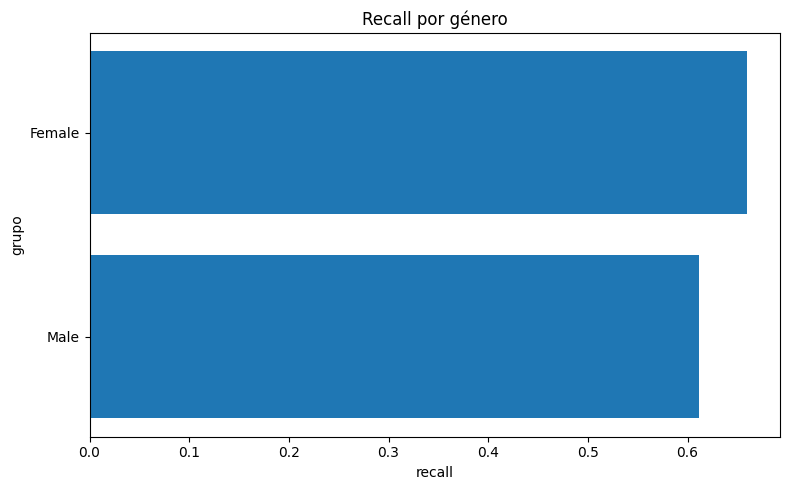

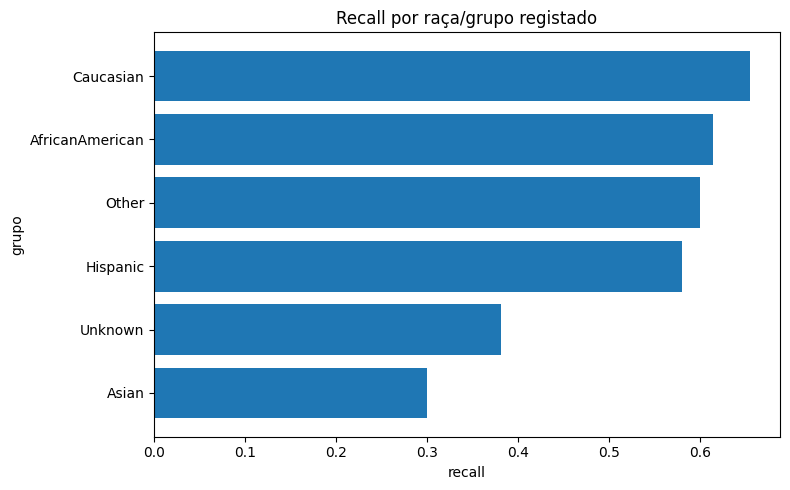

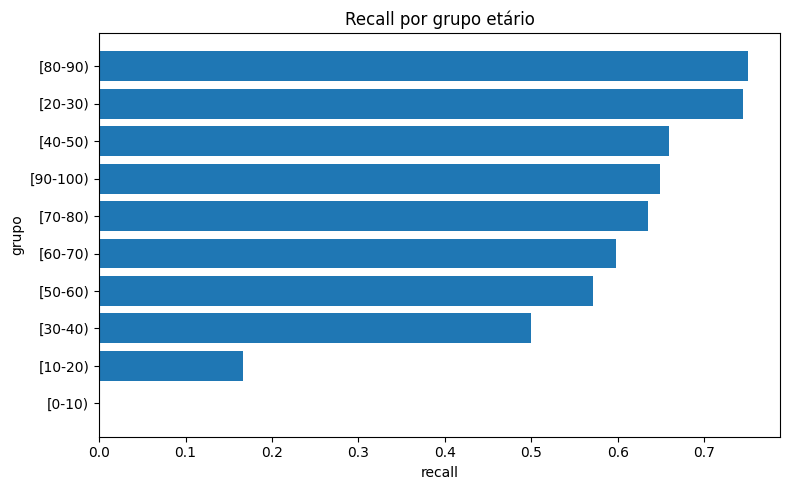

In [34]:
plot_group_metric(
    metrics_gender,
    "grupo",
    "recall",
    "Recall por género",
    "recall_por_genero.png"
)

plot_group_metric(
    metrics_race,
    "grupo",
    "recall",
    "Recall por raça/grupo registado",
    "recall_por_raca.png"
)

plot_group_metric(
    metrics_age,
    "grupo",
    "recall",
    "Recall por grupo etário",
    "recall_por_idade.png"
)

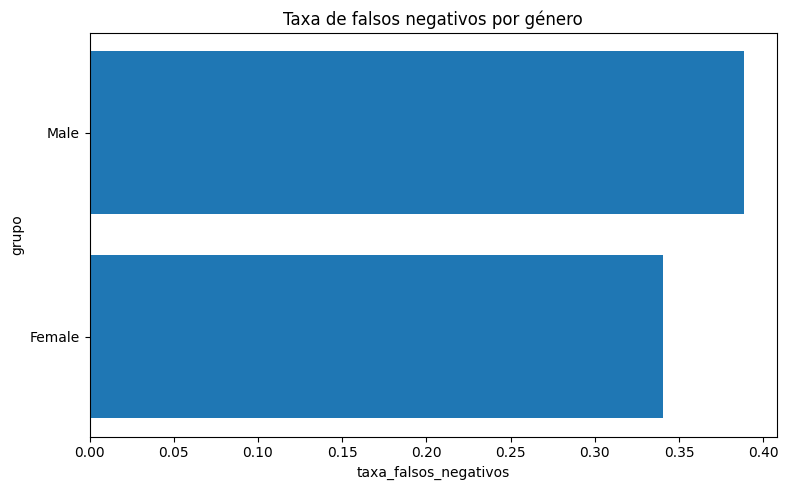

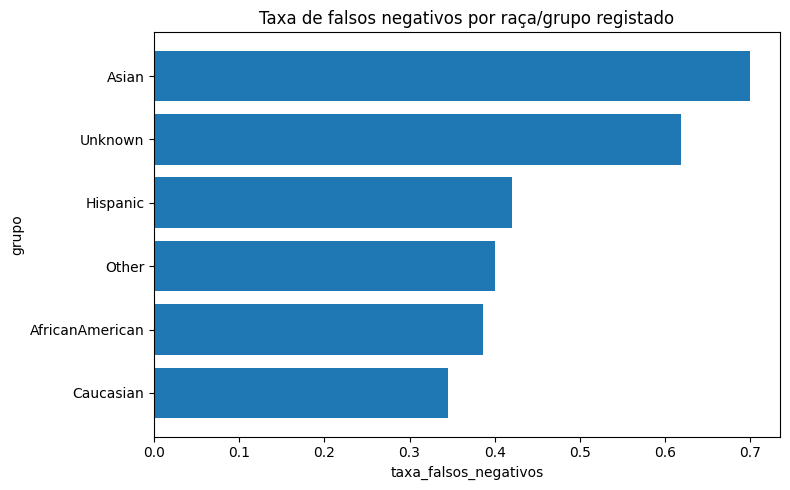

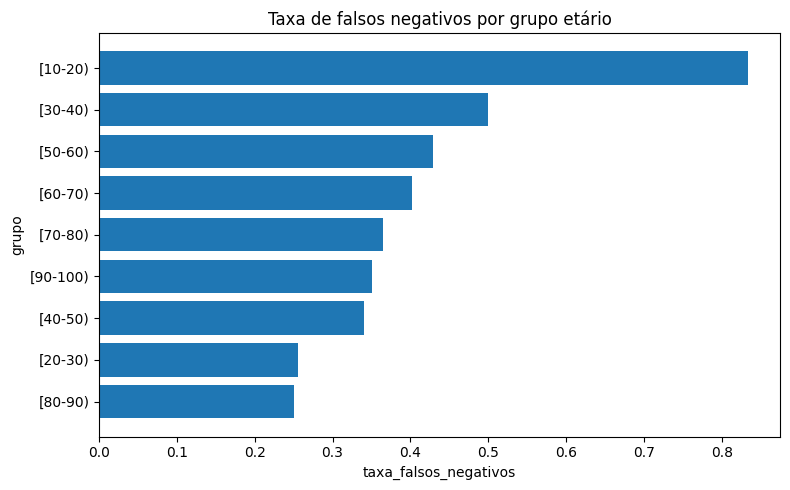

In [35]:
plot_group_metric(
    metrics_gender,
    "grupo",
    "taxa_falsos_negativos",
    "Taxa de falsos negativos por género",
    "falsos_negativos_por_genero.png"
)

plot_group_metric(
    metrics_race,
    "grupo",
    "taxa_falsos_negativos",
    "Taxa de falsos negativos por raça/grupo registado",
    "falsos_negativos_por_raca.png"
)

plot_group_metric(
    metrics_age,
    "grupo",
    "taxa_falsos_negativos",
    "Taxa de falsos negativos por grupo etário",
    "falsos_negativos_por_idade.png"
)

### Interpretação da análise por grupos

A análise por grupos mostra que o desempenho do modelo não é completamente uniforme entre diferentes categorias de género, raça e idade.

No caso do género, o modelo apresenta recall superior no grupo feminino do que no grupo masculino. Isto significa que identifica uma maior proporção de casos positivos entre mulheres, enquanto nos homens a taxa de falsos negativos é mais elevada.

Na análise por raça ou grupo registado, observa-se que grupos com menor número de observações, como `Asian`, `Hispanic`, `Other` e `Unknown`, apresentam maior instabilidade nas métricas. Esta instabilidade deve ser interpretada com cautela, uma vez que o reduzido número de exemplos pode amplificar variações nos resultados. Ainda assim, a existência de diferenças de recall e de taxas de falsos negativos entre grupos deve ser considerada um sinal de possível enviesamento ou desempenho desigual.

Na análise por idade, observam-se diferenças relevantes entre grupos etários. Alguns grupos apresentam taxas de falsos negativos mais elevadas, o que significa que o modelo falha com maior frequência na identificação de pacientes que acabam por ser readmitidos em menos de 30 dias. Este tipo de erro é particularmente importante em contexto de saúde, pois pode levar à não sinalização de pacientes que poderiam beneficiar de acompanhamento adicional.

De forma geral, a análise sugere que o modelo deve ser monitorizado por subgrupos antes de qualquer aplicação prática. Mesmo quando o desempenho global parece aceitável, podem existir diferenças relevantes entre grupos populacionais.

## 4.3 Riscos éticos do modelo

A utilização de um modelo de previsão de readmissão hospitalar em menos de 30 dias apresenta potenciais benefícios, mas também riscos éticos relevantes.

Do ponto de vista positivo, o modelo pode apoiar a identificação precoce de pacientes com maior risco de readmissão, permitindo reforçar o acompanhamento clínico, planear melhor os recursos hospitalares e prevenir reinternamentos evitáveis.

No entanto, existem riscos associados a erros de classificação. Os falsos negativos são particularmente críticos, porque correspondem a pacientes que foram efetivamente readmitidos em menos de 30 dias, mas que o modelo não identificou como estando em risco. Em contexto clínico, este tipo de erro pode levar à ausência de acompanhamento adicional para pacientes vulneráveis.

Os falsos positivos também têm impacto. Nestes casos, o modelo sinaliza pacientes como estando em risco, embora não venham a ser readmitidos. Isto pode levar ao uso desnecessário de recursos hospitalares, ansiedade para o paciente ou priorização inadequada.

Outro risco relevante é o uso indevido do modelo. Um sistema deste tipo deve ser utilizado para melhorar cuidados e apoiar decisões clínicas, e não como ferramenta para restringir acesso a cuidados, reduzir custos de forma cega ou substituir avaliação médica.

Assim, o modelo deve ser entendido como instrumento de apoio à decisão e não como sistema autónomo de decisão clínica.

Para enquadramento legal, vamos assumir contexto europeu/português. O AI Act é o Regulamento (UE) 2024/1689 e tem como objetivo promover IA centrada no ser humano e fiável, protegendo saúde, segurança e direitos fundamentais.   Como estamos a trabalhar com dados de saúde, também é relevante o RGPD, nomeadamente porque dados de saúde entram nas categorias especiais de dados pessoais

## 4.4 Privacidade e proteção de dados

O conjunto de dados utilizado contém informação relacionada com episódios hospitalares, diagnósticos, medicação, admissões, altas e readmissões. Por isso, trata-se de um domínio sensível do ponto de vista da proteção de dados.

Mesmo que o dataset não contenha nomes explícitos, variáveis como identificadores de paciente, dados clínicos, idade, género, raça, diagnósticos e histórico hospitalar podem levantar riscos de reidentificação se forem combinadas com outras fontes de dados.

Num contexto real, seria necessário garantir princípios como minimização dos dados, limitação da finalidade, pseudonimização, segurança do armazenamento, controlo de acessos e documentação das operações de tratamento.

A utilização de dados de saúde para modelação preditiva deve também respeitar os princípios do RGPD, sobretudo porque os dados de saúde são considerados dados pessoais sensíveis. Qualquer aplicação prática exigiria uma base legal adequada, avaliação de impacto, medidas técnicas e organizativas de proteção e governação clara dos dados.

Neste projeto, a análise é realizada com finalidade académica e exploratória. Ainda assim, é importante reconhecer que a transposição para contexto real exigiria salvaguardas adicionais de privacidade e conformidade legal.

## 4.5 Supervisão humana e responsabilidade

O modelo desenvolvido não deve ser utilizado como substituto da decisão clínica. A previsão algorítmica deve ser interpretada como um sinal de apoio, a ser considerado por profissionais de saúde no contexto de informação clínica mais ampla.

A supervisão humana é essencial por várias razões. Primeiro, o modelo apresenta desempenho limitado, com falsos positivos e falsos negativos relevantes. Segundo, o modelo baseia-se apenas nas variáveis disponíveis no dataset, podendo não captar fatores clínicos, sociais ou contextuais importantes. Terceiro, alguns grupos populacionais apresentam desempenho desigual, o que exige prudência na utilização prática.

A responsabilidade por decisões clínicas deve permanecer com profissionais qualificados e instituições responsáveis. O modelo pode ajudar a priorizar atenção, mas não deve determinar automaticamente decisões como alta, acompanhamento, recursos atribuídos ou intervenções clínicas.

Uma implementação responsável exigiria também monitorização contínua do desempenho, auditorias regulares, revisão por grupos populacionais, documentação do modelo, atualização periódica e mecanismos para contestar ou rever decisões apoiadas por IA.

## 4.6 Enquadramento regulamentar

Um sistema de IA aplicado à previsão de readmissão hospitalar insere-se num domínio sensível, pois está relacionado com saúde, segurança dos pacientes e potenciais impactos nos direitos fundamentais.

À luz do Regulamento Europeu da Inteligência Artificial, sistemas de IA utilizados em contextos de saúde podem exigir atenção especial, sobretudo quando influenciam decisões clínicas, priorização de cuidados ou gestão de risco do paciente. Mesmo quando usados apenas como apoio à decisão, estes sistemas devem ser avaliados em termos de risco, transparência, robustez, supervisão humana, qualidade dos dados e documentação.

Este tipo de sistema exigiria, numa aplicação real, documentação técnica adequada, registo das decisões de desenvolvimento, avaliação do desempenho, análise de enviesamento, monitorização após implementação e mecanismos de intervenção humana.

O modelo desenvolvido neste projeto deve, portanto, ser visto como um protótipo académico e não como sistema pronto para utilização clínica. A sua aplicação real exigiria validação externa, avaliação clínica, conformidade com legislação de proteção de dados, gestão de risco e supervisão institucional.